In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Original rows: 398
Rows removed: 6
Clustering data shape: (392, 2)


,horsepower,weight
count,392.000000,392.000000
mean,104.469388,2977.584184
std,38.491160,849.402560
min,46.000000,1613.000000
25%,75.000000,2225.250000
50%,93.500000,2803.500000
75%,126.000000,3614.750000
max,230.000000,5140.000000


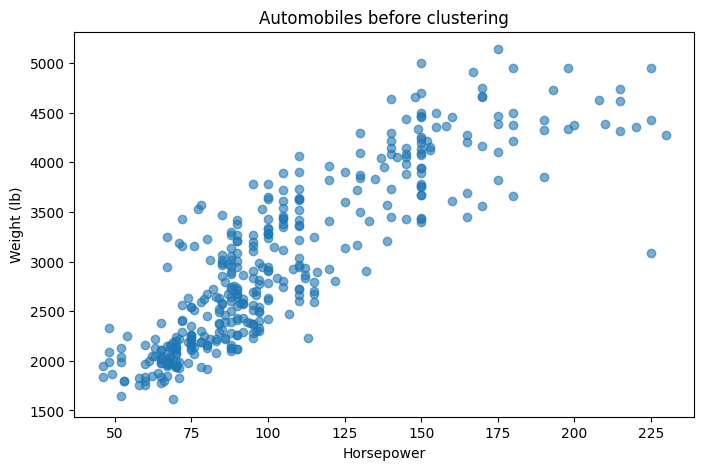

In [3]:
cars = sns.load_dataset("mpg")
car_features = ["horsepower", "weight"]
X_cars_df = cars[car_features].dropna().copy()
X_cars = X_cars_df.to_numpy()

print("Original rows:", len(cars))
print("Rows removed:", len(cars) - len(X_cars_df))
print("Clustering data shape:", X_cars.shape)
display(X_cars_df.describe())

plt.figure(figsize=(8, 5))
plt.scatter(X_cars_df["horsepower"], X_cars_df["weight"], alpha=0.6)
plt.xlabel("Horsepower")
plt.ylabel("Weight (lb)")
plt.title("Automobiles before clustering")
plt.show()

In [4]:
car_scaler = StandardScaler()
X_cars_scaled = car_scaler.fit_transform(X_cars_df)

scaled_summary = pd.DataFrame(X_cars_scaled, columns=car_features)
print("Means after scaling:")
print(scaled_summary.mean().round(6))
print("Standard deviations after scaling:")
print(scaled_summary.std(ddof=0).round(6))

Means after scaling:
horsepower   -0.0
weight       -0.0
dtype: float64
Standard deviations after scaling:
horsepower    1.0
weight        1.0
dtype: float64


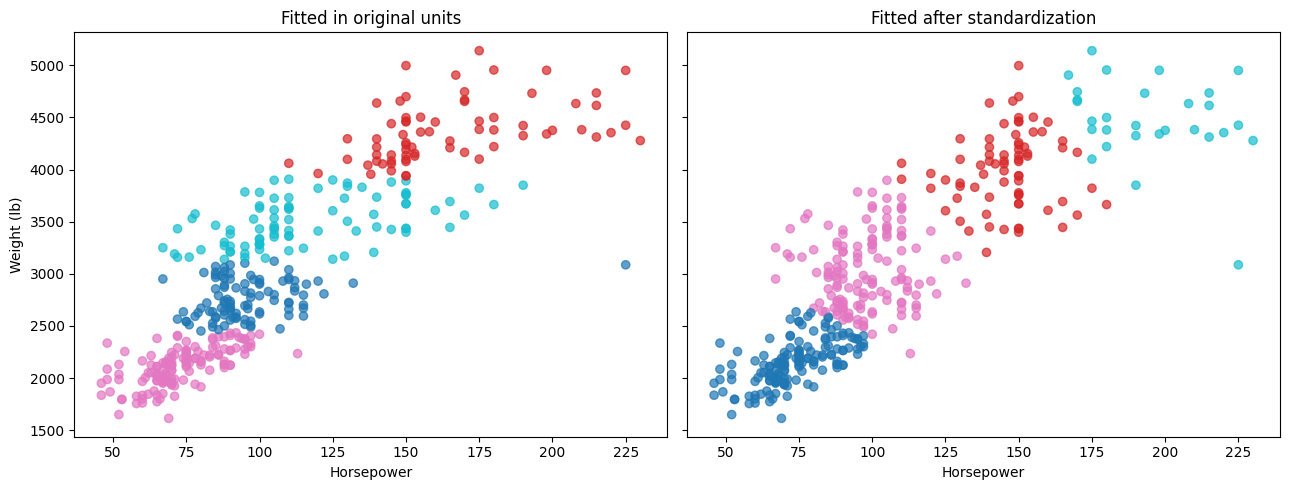

In [5]:
raw_model = KMeans(n_clusters=4, random_state=42, n_init=10)
raw_labels = raw_model.fit_predict(X_cars)

scaled_model = KMeans(n_clusters=4, random_state=42, n_init=10)
scaled_labels = scaled_model.fit_predict(X_cars_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, group_labels, title in [
    (axes[0], raw_labels, "Fitted in original units"),
    (axes[1], scaled_labels, "Fitted after standardization")
]:
    ax.scatter(X_cars[:, 0], X_cars[:, 1], c=group_labels, cmap="tab10", alpha=0.7)
    ax.set_xlabel("Horsepower")
    ax.set_title(title)
axes[0].set_ylabel("Weight (lb)")
plt.tight_layout()
plt.show()

In [6]:
print("Inertia for the scaled K = 4 model:", scaled_model.inertia_)

Inertia for the scaled K = 4 model: 98.5088650871608


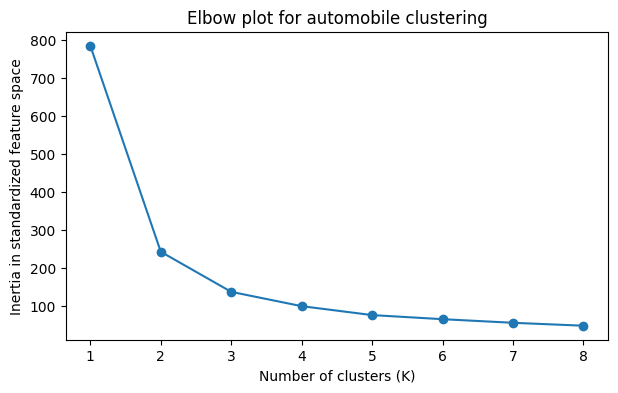

In [7]:
car_models = {}
car_labels_by_k = {}
inertia_rows = []

for k in range(1, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    group_labels = model.fit_predict(X_cars_scaled)
    car_models[k] = model
    car_labels_by_k[k] = group_labels
    inertia_rows.append({"K": k, "Inertia": model.inertia_})

inertia_table = pd.DataFrame(inertia_rows)
plt.figure(figsize=(7, 4))
plt.plot(inertia_table["K"], inertia_table["Inertia"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia in standardized feature space")
plt.title("Elbow plot for automobile clustering")
plt.show()

,K,Inertia,Silhouette
0,1,784.000,NaN
1,2,241.704,0.615
2,3,136.206,0.500
3,4,98.509,0.481
4,5,75.027,0.438
5,6,64.245,0.428
6,7,54.748,0.383
7,8,47.040,0.408


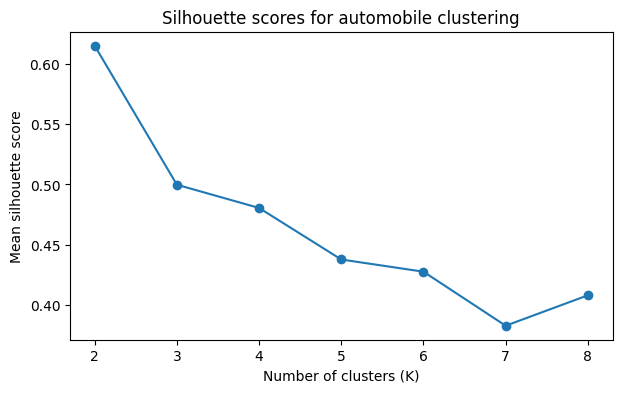

In [8]:
silhouette_rows = []
for k in range(2, 9):
    score = silhouette_score(X_cars_scaled, car_labels_by_k[k])
    silhouette_rows.append({"K": k, "Silhouette": score})

silhouette_table = pd.DataFrame(silhouette_rows)
selection_table = inertia_table.merge(silhouette_table, on="K", how="left")
display(selection_table.round(3))

plt.figure(figsize=(7, 4))
plt.plot(silhouette_table["K"], silhouette_table["Silhouette"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Mean silhouette score")
plt.title("Silhouette scores for automobile clustering")
plt.show()

0    156
1     95
2    141
Name: count, dtype: int64


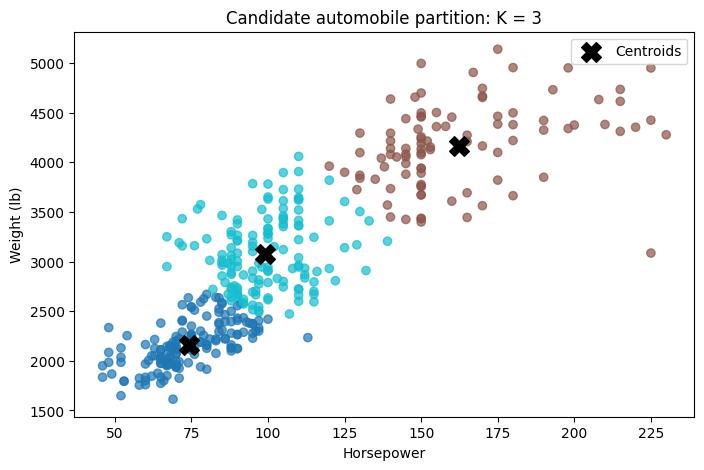

In [9]:
chosen_k = 3  # Candidate for inspection, not a declared optimum.
assert chosen_k in range(2, 9), "Choose an integer K from 2 through 8."
chosen_model = car_models[chosen_k]
chosen_labels = car_labels_by_k[chosen_k]
centers_original = car_scaler.inverse_transform(chosen_model.cluster_centers_)

print(pd.Series(chosen_labels).value_counts().sort_index())
plt.figure(figsize=(8, 5))
plt.scatter(X_cars[:, 0], X_cars[:, 1], c=chosen_labels, cmap="tab10", alpha=0.7)
plt.scatter(
    centers_original[:, 0], centers_original[:, 1],
    marker="X", s=200, c="black", label="Centroids"
)
plt.xlabel("Horsepower")
plt.ylabel("Weight (lb)")
plt.title(f"Candidate automobile partition: K = {chosen_k}")
plt.legend()
plt.show()

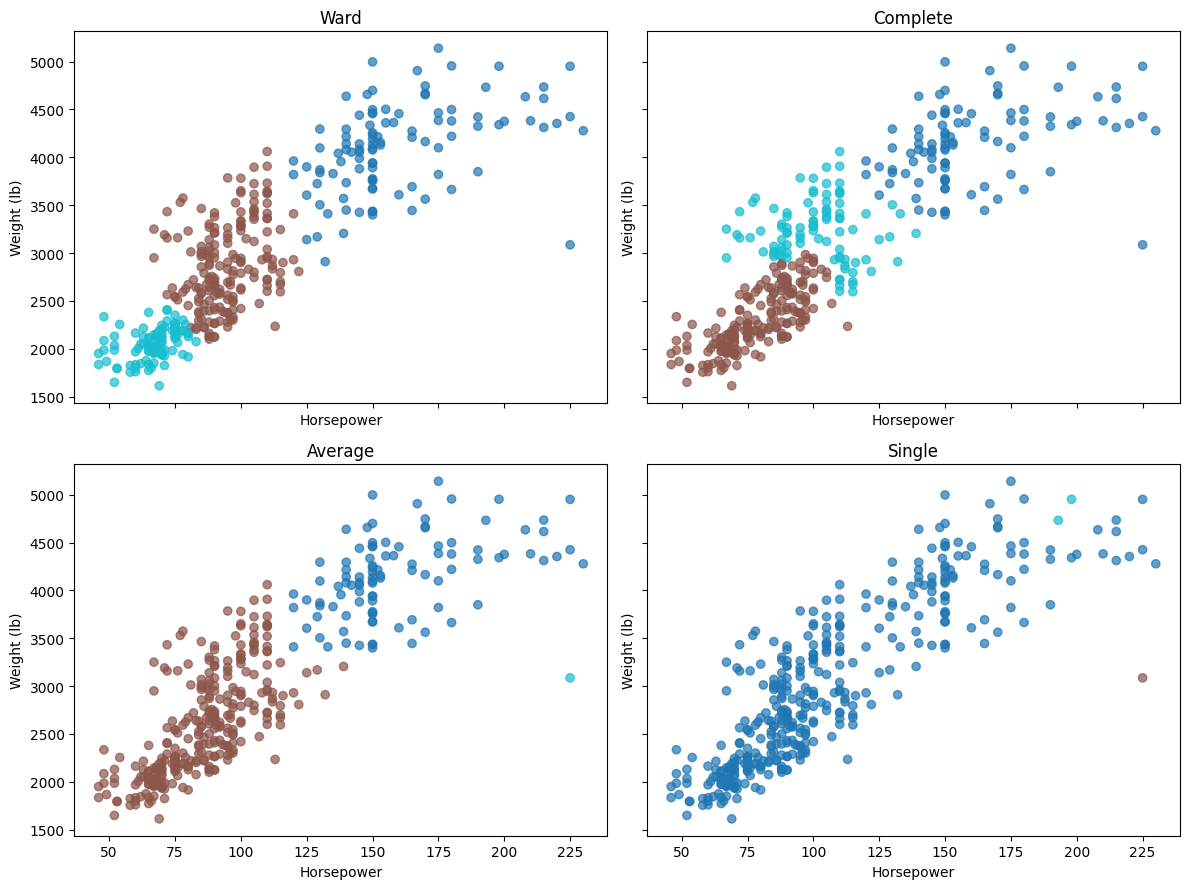

,Linkage,Silhouette,Smallest group,Largest group
0,ward,0.466,102,187
1,complete,0.461,94,201
2,average,0.585,1,292
3,single,0.386,1,389


In [10]:
linkage_methods = ["ward", "complete", "average", "single"]
hierarchical_results = []
hierarchical_labels_by_method = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

for ax, method in zip(axes.flat, linkage_methods):
    model = AgglomerativeClustering(n_clusters=chosen_k, linkage=method)
    group_labels = model.fit_predict(X_cars_scaled)
    hierarchical_labels_by_method[method] = group_labels
    counts = pd.Series(group_labels).value_counts()
    hierarchical_results.append({
        "Linkage": method,
        "Silhouette": silhouette_score(X_cars_scaled, group_labels),
        "Smallest group": counts.min(),
        "Largest group": counts.max()
    })
    ax.scatter(X_cars[:, 0], X_cars[:, 1], c=group_labels, cmap="tab10", alpha=0.7)
    ax.set_title(method.capitalize())
    ax.set_xlabel("Horsepower")
    ax.set_ylabel("Weight (lb)")
plt.tight_layout()
plt.show()
display(pd.DataFrame(hierarchical_results).round(3))

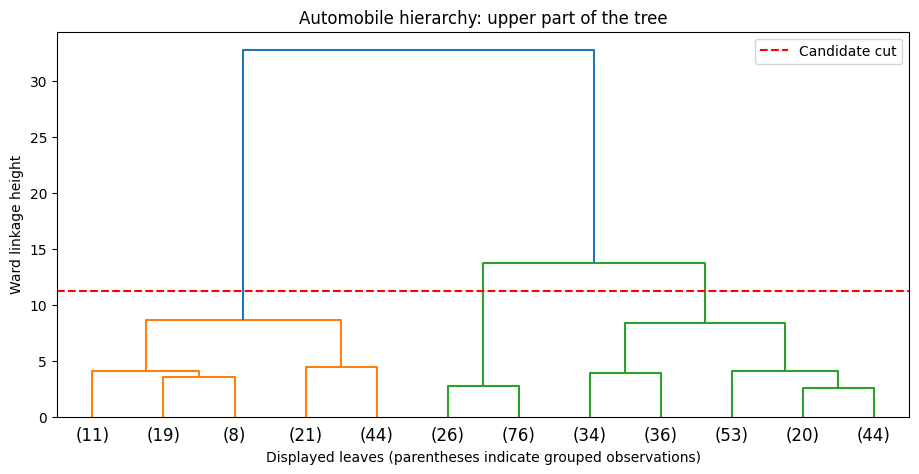

Clusters at this cut: 3
1    103
2    102
3    187
Name: count, dtype: int64


In [11]:
Z_cars = linkage(X_cars_scaled, method="ward")

lower_height = Z_cars[-chosen_k, 2]
upper_height = Z_cars[-(chosen_k - 1), 2]
cut_height = (lower_height + upper_height) / 2

plt.figure(figsize=(11, 5))
dendrogram(Z_cars, truncate_mode="lastp", p=12, show_leaf_counts=True)
plt.axhline(cut_height, color="red", linestyle="--", label="Candidate cut")
plt.xlabel("Displayed leaves (parentheses indicate grouped observations)")
plt.ylabel("Ward linkage height")
plt.title("Automobile hierarchy: upper part of the tree")
plt.legend()
plt.show()

cut_labels = fcluster(Z_cars, t=cut_height, criterion="distance")
print("Clusters at this cut:", len(np.unique(cut_labels)))
print(pd.Series(cut_labels).value_counts().sort_index())

In [12]:
car_profiles_data = X_cars_df.copy()
car_profiles_data["Cluster"] = chosen_labels
car_profiles_data["Silhouette"] = silhouette_samples(X_cars_scaled, chosen_labels)

car_profiles = car_profiles_data.groupby("Cluster").agg(
    Cars=("horsepower", "size"),
    MeanHorsepower=("horsepower", "mean"),
    MeanWeight=("weight", "mean"),
    MeanSilhouette=("Silhouette", "mean"),
    NegativeSilhouetteFraction=("Silhouette", lambda s: (s < 0).mean())
)
display(car_profiles.round(3))

,Cars,MeanHorsepower,MeanWeight,MeanSilhouette,NegativeSilhouetteFraction
Cluster,,,,,
0,156,74.109,2164.205,0.578,0.000
1,95,162.337,4168.284,0.506,0.000
2,141,99.071,3075.248,0.409,0.043


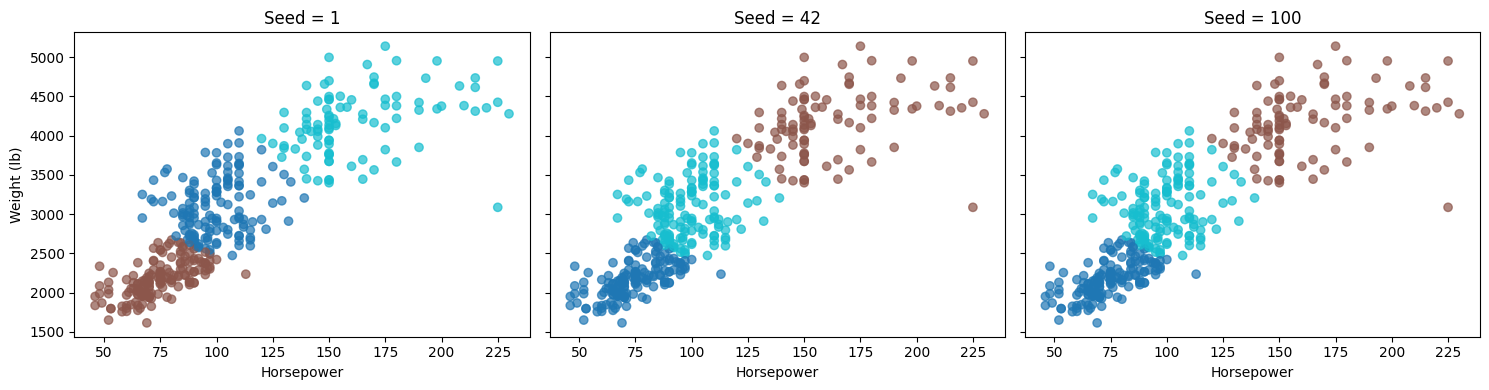

,Seed,Inertia,Silhouette
0,1,136.203,0.499
1,42,136.206,0.500
2,100,136.206,0.500


In [13]:
stability_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, seed in zip(axes, [1, 42, 100]):
    model = KMeans(n_clusters=chosen_k, random_state=seed, n_init=10)
    group_labels = model.fit_predict(X_cars_scaled)
    stability_rows.append({
        "Seed": seed,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_cars_scaled, group_labels)
    })
    ax.scatter(X_cars[:, 0], X_cars[:, 1], c=group_labels, cmap="tab10", alpha=0.7)
    ax.set_title(f"Seed = {seed}")
    ax.set_xlabel("Horsepower")
axes[0].set_ylabel("Weight (lb)")
plt.tight_layout()
plt.show()
display(pd.DataFrame(stability_rows).round(3))

In [14]:
credit_url = (
    "https://raw.githubusercontent.com/AI-Learning-Repo/"
    "Data-Handling/refs/heads/week5/datasets/credit_card.csv"
)
credit_card = pd.read_csv(credit_url)
credit_features = credit_card.drop(columns=["CUST_ID"]).select_dtypes(include="number")
credit_features = credit_features.dropna(axis=1, how="all").copy()

print("Customer rows and selected features:", credit_features.shape)
print("Missing measurements:")
print(credit_features.isna().sum())
display(credit_features.head())

X_credit = credit_features.fillna(credit_features.median())

Customer rows and selected features: (8950, 17)
Missing measurements:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


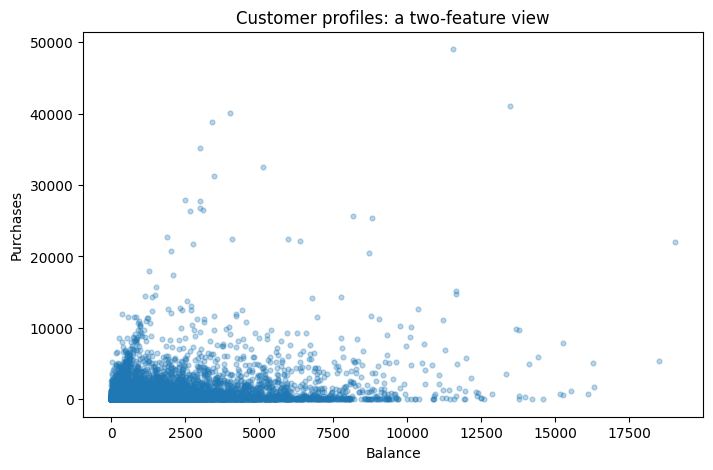

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(X_credit["BALANCE"], X_credit["PURCHASES"], alpha=0.3, s=12)
plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("Customer profiles: a two-feature view")
plt.show()

In [16]:
isolation_model = IsolationForest(contamination=0.02, random_state=42)
credit_flags = isolation_model.fit_predict(X_credit)

credit_results = credit_card.copy()
credit_results["Flag"] = credit_flags
credit_results["NormalityScore"] = isolation_model.score_samples(X_credit)
print(credit_results["Flag"].value_counts())

Flag
 1    8771
-1     179
Name: count, dtype: int64


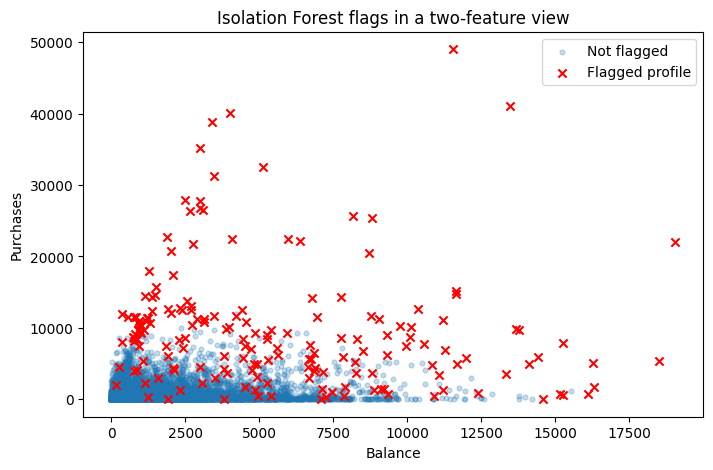

,CUST_ID,BALANCE,PURCHASES,CASH_ADVANCE,Flag,NormalityScore
138,C10144,19043.13856,22009.92,0.000000,-1,-0.751936
501,C10523,13479.28821,41050.40,0.000000,-1,-0.746104
153,C10159,13673.07961,9792.23,2444.445738,-1,-0.744937
550,C10574,11547.52001,49039.57,558.166886,-1,-0.743100
4515,C14640,6956.37654,11500.94,15133.532130,-1,-0.742924


In [17]:
flagged = credit_flags == -1
plt.figure(figsize=(8, 5))
plt.scatter(
    X_credit.loc[~flagged, "BALANCE"], X_credit.loc[~flagged, "PURCHASES"],
    alpha=0.25, s=12, label="Not flagged"
)
plt.scatter(
    X_credit.loc[flagged, "BALANCE"], X_credit.loc[flagged, "PURCHASES"],
    marker="x", c="red", s=35, label="Flagged profile"
)
plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("Isolation Forest flags in a two-feature view")
plt.legend()
plt.show()

display(credit_results.nsmallest(5, "NormalityScore")[[
    "CUST_ID", "BALANCE", "PURCHASES", "CASH_ADVANCE", "Flag", "NormalityScore"
]])

In [18]:
threshold_rows = []
for fraction in [0.01, 0.02, 0.05]:
    model = IsolationForest(contamination=fraction, random_state=42)
    flags = model.fit_predict(X_credit)
    threshold_rows.append({
        "Contamination setting": fraction,
        "Flagged customers": int((flags == -1).sum()),
        "Flagged fraction": float((flags == -1).mean())
    })
display(pd.DataFrame(threshold_rows))

,Contamination setting,Flagged customers,Flagged fraction
0,0.01,90,0.010056
1,0.02,179,0.020000
2,0.05,448,0.050056
